/tmp/ipykernel_3374/267441191.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('RELIANCE.NS', start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2010-01-04  218.593094  221.763765  207.688857  221.763765    76646086
2010-01-05  217.617462  233.714707  216.540252  233.714707    21392825
2010-01-06  221.133667  222.454781  217.607309  219.487352    23691760
2010-01-07  224.802307  226.621378  219.101204  221.133693    26197920
2010-01-08  224.212921  226.377517  222.759699  225.198672    15110149
Price             Close         High          Low         Open      Volume
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS
Date                                                                      
2024-11-21  1218.134888  1239.001500  1212.407761  1236.710722    19433843
2024-11-22  1260.366211  1263.802438  1217.586995  1224.509420    20471957
2024-11-25  1281.880249  1299.260783  1277.348301  1284.8

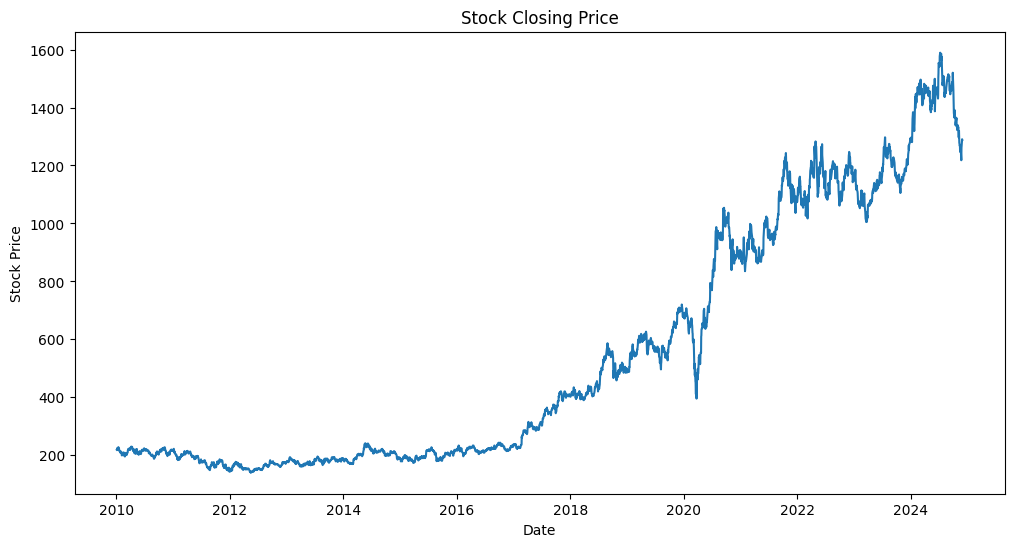

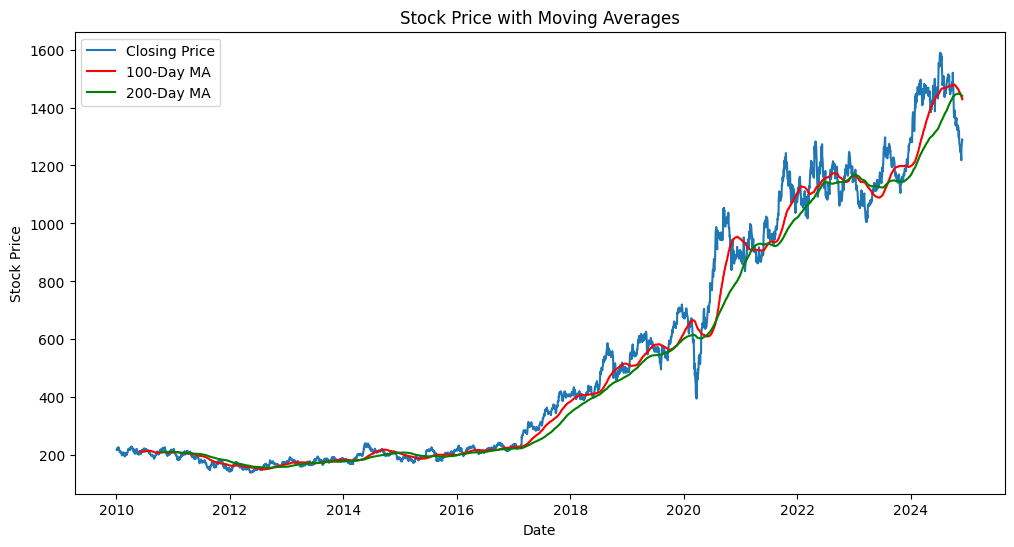

(2573, 1) (1104, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 100, 100)       │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 100, 120)       │        77,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 120)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 100, 160)       │       128,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 160)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 240)            │       269,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 240)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 496,721 (1.89 MB)

 Trainable params: 496,721 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 28s 160ms/step - loss: 0.0174
Epoch 2/20
64/78 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0045

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Bidirectional
from sklearn.model_selection import train_test_split

# Load data
start = '2010-01-01'
end = '2024-11-28'
# Changed stock symbol to a valid one, e.g., RELIANCE.NS
df = yf.download('RELIANCE.NS', start=start, end=end)

# Display data
print(df.head())
print(df.tail())

# Reset index to make 'Date' a column
df.reset_index(inplace=True)

# Convert 'Date' column to datetime objects for proper plotting
df['Date'] = pd.to_datetime(df['Date'])

# Check and adjust columns
print(df.columns)
# Removed dropping 'Date' column as it's useful for plotting time series
# The 'Date' column will be used as the x-axis for plots

# 'Adj Close' might be redundant with 'Close' if auto_adjust=True, so drop it if present.
if 'Adj Close' in df.columns:
    df.drop(['Adj Close'], axis=1, inplace=True)
print(df.head())

# Plot closing price
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close']) # Use 'Date' for x-axis
plt.title('Stock Closing Price')
plt.xlabel('Date') # Changed label from 'Time' to 'Date'
plt.ylabel('Stock Price')
plt.show()

# Moving Averages
ma100 = df['Close'].rolling(100).mean()
ma200 = df['Close'].rolling(200).mean()

# Plot moving averages
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Closing Price') # Use 'Date' for x-axis
plt.plot(df['Date'], ma100, 'r', label='100-Day MA') # Use 'Date' for x-axis
plt.plot(df['Date'], ma200, 'g', label='200-Day MA') # Use 'Date' for x-axis
plt.title('Stock Price with Moving Averages')
plt.xlabel('Date') # Changed label from 'Time' to 'Date'
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# Split data
training_size = int(len(df) * 0.70)
# Ensure we are working with the 'Close' prices for training/testing
data_training = df['Close'][:training_size]
data_testing = df['Close'][training_size:]
print(data_training.shape, data_testing.shape)

# Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
data_training_scaled = scaler.fit_transform(np.array(data_training).reshape(-1,1))

# Prepare training sequences
x_train, y_train = [], []
for i in range(100, len(data_training_scaled)):
    x_train.append(data_training_scaled[i-100:i, 0])
    y_train.append(data_training_scaled[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Define BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(units=50, activation='relu', return_sequences=True), input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(Bidirectional(LSTM(units=60, activation='relu', return_sequences=True)))
model.add(Dropout(0.3))

model.add(Bidirectional(LSTM(units=80, activation='relu', return_sequences=True)))
model.add(Dropout(0.4))

model.add(Bidirectional(LSTM(units=120, activation='relu')))
model.add(Dropout(0.5))

model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Train model
model.fit(x_train, y_train, epochs=20, batch_size=32)

# Save model
model.save('bilstm_stock_model.h5')

# Prepare test data
past_100_days = df['Close'].tail(100)
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

# Normalize test data
input_data = scaler.transform(np.array(final_df).reshape(-1,1))

# Prepare test sequences
x_test, y_test = [], []
for i in range(100, len(input_data)):
    x_test.append(input_data[i-100:i, 0])
    y_test.append(input_data[i, 0])
x_test, y_test = np.array(x_test), np.array(y_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Predict
y_predicted = model.predict(x_test)
scale_factor = 1 / scaler.scale_[0]
y_predicted = y_predicted * scale_factor
y_test = y_test * scale_factor

# Plot results
plt.figure(figsize=(14,5))
# Use the dates corresponding to the testing data for the x-axis
plt.plot(df['Date'][training_size:], y_test, color='blue', label='Actual Stock Price')
plt.plot(df['Date'][training_size:], y_predicted, color='red', linestyle='dashed', label='Predicted Stock Price')
plt.title('Stock Price Prediction using BiLSTM')
plt.xlabel('Date') # Changed label from 'Time' to 'Date'
plt.ylabel('Stock Price')
plt.legend()
plt.show()